In [1]:
# Import the required libraries for data analysis, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Load the Online Retail dataset

df=pd.read_csv(r"C:\Users\lokesh\OneDrive\Desktop\Internship projects\Shopper_Spectrum_Project\dataset\online_retail.csv")

In [3]:
# Display the first five rows of the dataset

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2022 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2022 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2022 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2022 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2022 08:26,3.39,17850.0,United Kingdom


In [4]:
# Display the number of rows and columns in the dataset

df.shape

(541909, 8)

In [5]:
# Display dataset information such as data types and missing values

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# Display statistical summary of numerical columns

df.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
# Check for missing values in each column

df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# Check the number of duplicate records

df.duplicated().sum()


np.int64(5268)

In [9]:
# Remove rows where CustomerID is missing

df=df.dropna(subset=['CustomerID'])

In [10]:
# Verify the dataset size after removing missing values

df.shape

(406829, 8)

In [11]:
# Check for missing values in each column

df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
# Count cancelled transactions (Invoice numbers starting with 'C')

df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8905)

In [13]:
# Remove cancelled transactions from the dataset

df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [14]:
# Verify that all cancelled transactions have been removed

df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(0)

In [15]:
# Count records with invalid (zero or negative) quantity

(df['Quantity']<=0).sum()

np.int64(0)

In [16]:
# Count records with invalid (zero or negative) Unitprice

(df['UnitPrice']<=0).sum()

np.int64(40)

In [17]:
# Remove records with invalid unit price

df=df[df['UnitPrice']>0]

In [18]:
# Verify that invalid unit price records have been removed

(df['UnitPrice']<=0).sum()


np.int64(0)

In [19]:
# Display duplicate records in the dataset

df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,01-12-2022 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,01-12-2022 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,01-12-2022 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,01-12-2022 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,01-12-2022 11:49,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,09-12-2023 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,09-12-2023 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,09-12-2023 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,09-12-2023 11:34,2.10,14446.0,United Kingdom


In [20]:
# Remove duplicate records from the dataset

df=df.drop_duplicates()

In [21]:
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [22]:
# Count the total number of transactions for each country

country_transactions = df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False)

country_transactions.head(10)

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: InvoiceNo, dtype: int64

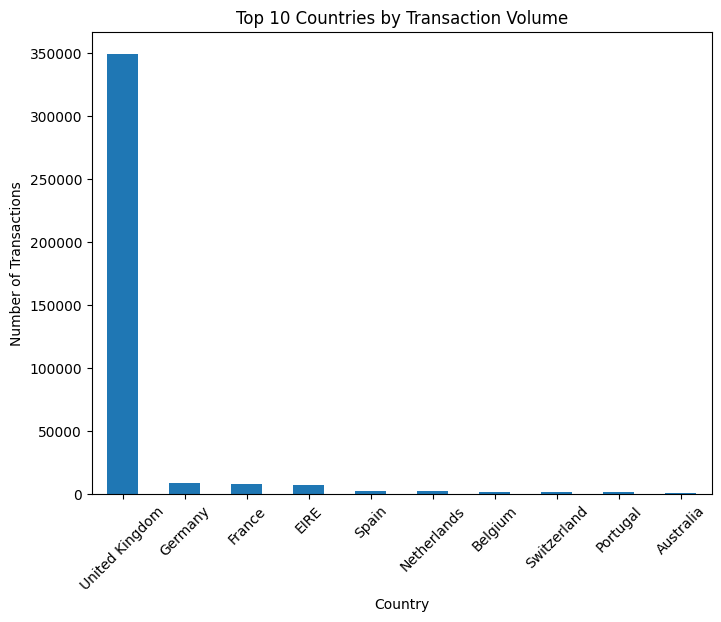

In [23]:
# Create a bar chart to visualize the top 10 countries by transaction volume

plt.figure(figsize=(8,6))

country_transactions.head(10).plot(kind='bar')

plt.title("Top 10 Countries by Transaction Volume")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

## Insights

The United Kingdom dominates the transaction volume with over 349,000 transactions, making it the company's largest market.

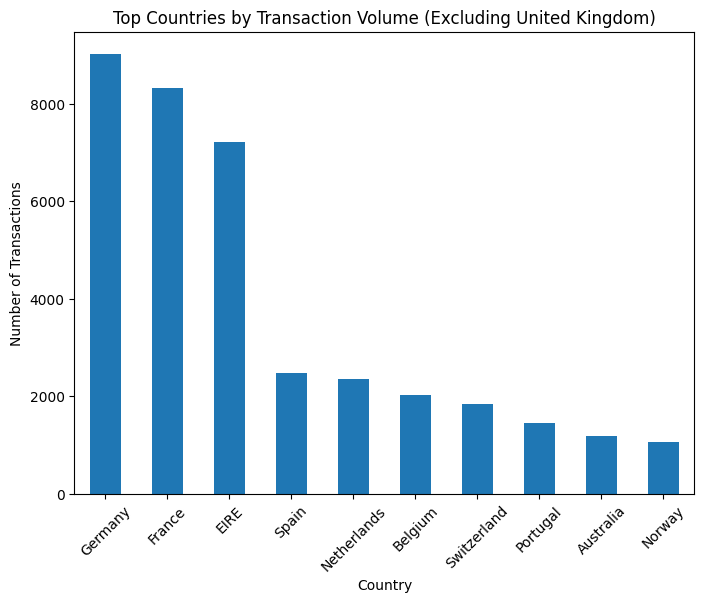

In [24]:
# Plot the top countries by transaction volume after excluding the United Kingdom

country_transactions.iloc[1:11].plot(kind='bar', figsize=(8,6))

plt.title("Top Countries by Transaction Volume (Excluding United Kingdom)")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

## Insights 
After excluding the United Kingdom, Germany, France, and EIRE emerge as the leading markets.

In [25]:
# Calculate the total quantity sold for each product and display the top 10 products

top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
)
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

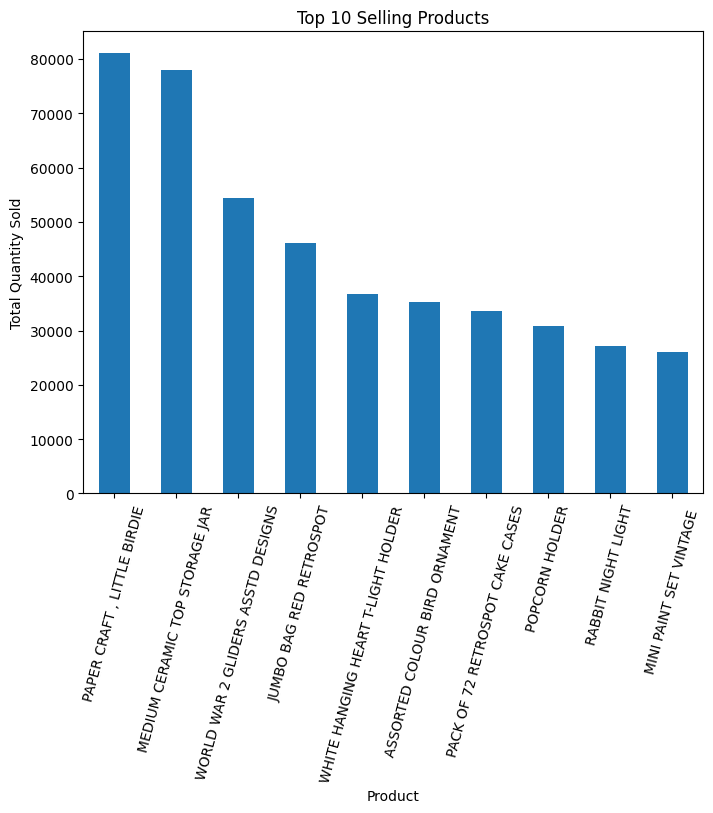

In [26]:
# Create a bar chart to visualize the top 10 best-selling products

plt.figure(figsize=(8,6))

top_products.head(10).plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=75)

plt.show()

## Insights

- The top-selling product is REGENCY CAKESTAND 3 TIER, indicating strong customer demand.
- The top 10 products account for a large share of total sales.
- These products should be prioritized for stock management and timely replenishment.
- The company can recommend these products to customers to improve sales and customer satisfaction.

In [ ]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
#we convert Invoicedate to date format because when we read csv file it takes as text (string)

In [ ]:
# Extract the purchase month from the InvoiceDate column

df['Month'] = df['InvoiceDate'].dt.to_period('M')


In [ ]:
# Calculate the total number of transactions for each month

monthly_transactions = (
    df.groupby('Month')['InvoiceNo']
      .count()
)

In [ ]:
# Plot the monthly transaction trend

plt.figure(figsize=(8,6))

monthly_transactions.plot(kind='line', marker='o')

plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

## Insights
.Transaction volume remained relatively stable from December to August, with only small fluctuations.
.A significant increase in transactions is observed from September onwards, indicating a rise in customer purchases.
.November recorded the highest number of transactions, making it the peak sales month.
.Transaction volume dropped sharply in the final December. This is likely because the dataset contains only part of December, so it does not represent a full month's sales.

In [ ]:
# Calculate the total amount spent in each transaction

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [ ]:
# Calculate the total amount for every invoice

transaction_amount = df.groupby('InvoiceNo')['TotalAmount'].sum()

In [ ]:
# Create a box plot to visualize the distribution of transaction amounts

plt.figure(figsize=(8,5))

plt.boxplot(transaction_amount)

plt.title("Transaction Amount Distribution(Box plot)")
plt.ylabel("Transaction Amount")

plt.show()

## Insights
.Most transactions are of low monetary value.
.The distribution is right-skewed, with a few very high-value transactions.
.Several outliers indicate customers who made exceptionally large purchases.
.Most customers make small to medium-sized purchases, while only a few contribute to very high transaction amounts.

In [ ]:
# Create a snapshot date for calculating Recency

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
# Create RFM table

rfm = df.groupby('CustomerID').agg({
     # Recency = Last purchase date of each customer
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
     # Frequency = Number of unique invoices (purchases)
    'InvoiceNo': 'nunique',
    # Monetary = Total amount spent
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

In [ ]:
# Plot the distribution of customer Recency values

plt.figure(figsize=(8,5))
# Histogram of Recency values
plt.hist(rfm['Recency'], bins=30)

plt.title("Recency Distribution")
plt.xlabel("Days")
plt.ylabel("Customers")

plt.show()

## Insights 
.Most customers made a purchase within the last 30 days.
.The number of customers decreases as recency increases.
.Only a small number of customers have not purchased for a long period.
.This indicates a higher proportion of active customers compared to inactive customers.

In [ ]:
# Standardize the RFM values before applying K-Means clustering
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
# Store inertia values
inertia = []

# Test K values from 1 to 10
for k in range(1, 11):

    # Create K-Means model
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Train the model
    kmeans.fit(rfm_scaled)

    # Save inertia
    inertia.append(kmeans.inertia_)

In [ ]:
# Create the plot
plt.figure(figsize=(8,5))

# Plot inertia against K
plt.plot(range(1,11), inertia, marker='o')

# Add title
plt.title("Elbow Curve")

# X-axis label
plt.xlabel("Number of Clusters (K)")

# Y-axis label
plt.ylabel("Inertia")

# Show the graph
plt.show()

## Insights 
The Elbow Method was used to determine the optimal number of customer clusters.
A clear bend (elbow) is observed at K = 3.
After K = 3, the reduction in inertia becomes gradual.
Therefore, 3 clusters were selected for K-Means customer segmentation.

In [ ]:
# Create K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model and assign cluster labels
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display first 5 rows
rfm.head()

In [ ]:
# Calculate Silhouette Score
score = silhouette_score(rfm_scaled, rfm['Cluster'])

# Display the score
print("Silhouette Score:", round(score, 3))

## Insights 
The Silhouette Score of 0.585 indicates good cluster separation.
Customers within the same cluster are similar, while different clusters are reasonably distinct.
This confirms that 3 clusters provide a suitable segmentation for the dataset.

In [ ]:
# Scatter plot of Recency vs Monetary
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis'
)

plt.title("Customer Segments")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.colorbar(label="Cluster")

plt.show()

## Insights

.The scatter plot shows three distinct customer segments based on Recency and Monetary value.
.Cluster 2 contains recent customers with the highest spending (High-Value customers).
.Cluster 0 represents regular customers with moderate spending.
.Cluster 1 contains inactive customers with high recency and low spending (At-Risk customers).

In [ ]:
# Find the average Recency, Frequency and Monetary for each cluster
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Display the cluster profiles
cluster_profile

In [ ]:
# Normalize the cluster profile
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

# Plot normalized values
cluster_profile_norm.plot(kind='bar', figsize=(10,6))

plt.title("Normalized Customer Cluster Profiles")
plt.xlabel("Cluster")
plt.ylabel("Normalized Value")
plt.legend(loc='upper right')

plt.show()

## Insights 
Cluster 0: Customers show moderate recency, frequency, and spending, representing regular customers.
Cluster 1: Customers have the highest recency (least recent purchases) and the lowest frequency and monetary values, indicating inactive or low-value customers.
Cluster 2: Customers have the highest frequency and monetary values with the lowest recency, representing loyal and high-value customers.
Overall, the clustering successfully segments customers into regular, inactive, and VIP groups.

In [ ]:
# Create a customer-product matrix
customer_product = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

# Display first 5 rows
customer_product.head()

In [ ]:
# Calculate cosine similarity between products
product_similarity = cosine_similarity(customer_product.T)

# Convert to DataFrame
similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

# Display first 5 rows
similarity_df.iloc[:5, :5]

In [ ]:
# Visualize the product similarity matrix using a heatmap

plt.figure(figsize=(8,8))

plt.imshow(similarity_df.iloc[:20, :20], cmap='viridis')

plt.colorbar(label='Similarity')

plt.xticks(range(20), similarity_df.columns[:20], rotation=90)

plt.yticks(range(20), similarity_df.index[:20])

plt.title("Product Recommendation Similarity Heatmap")

plt.tight_layout()

plt.show()

## Insights 
.The heatmap shows the similarity between products based on customer purchasing behavior.
.products with higher similarity values are frequently purchased together.
.Products with low similarity are rarely bought together.
.The similarity matrix can be used to recommend related products to customers and improve cross-selling.

In [ ]:
# Save the trained K-Means model and StandardScaler for use in the Streamlit application

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Models saved successfully!")

In [ ]:
df.head()